# Stage 2: Data Acquisition, Exploration, and Preprocessing

This task involves a deep dive into the dataset to identify linguistic patterns, class imbalances, and noise. If the noise can be cleaned easily, we ensure higher quality inputs for the binary classifiers and a more reliable training process downstream.

## Exploratory Data Analysis (EDA) in NLP

Exploratory Data Analysis (EDA) in NLP focuses on uncovering linguistic patterns, structural properties, biases, and noise within text data before model training.

Skipping EDA means training blindly. Performing it leads to better modeling decisions.

---

### 1. Basic Statistical Profiling

Understand dataset structure before examining content.

- **Token Count**  
  Average, minimum, and maximum sentence length; helps determine `max_length` for transformer models.

- **Vocabulary Size**  
  Number of unique words; influences embedding size and model capacity.

- **Class Distribution**  
  Check for imbalance; prevents misleading metrics (for example, high accuracy from majority class guessing).

Outcome: decide on class weighting, resampling, or augmentation, and set appropriate sequence length.

---

### 2. Lexical Analysis (Word-Level Patterns)

Examine the actual words used in the dataset.

- **N-gram Analysis**  
  Identify frequent bigrams/trigrams; detect domain-specific phrases.

- **Stopword Density**  
  Estimate filler content; inform cleaning strategy.

- **Word Frequency / Word Clouds**  
  Quick visual check to ensure frequent words align with the task intent.

Outcome: detect shortcuts the model might exploit and identify task-relevant keywords.

---

### 3. Semantic & Syntactic Exploration

Go beyond surface statistics into linguistic structure.

- **POS Tagging**  
  Analyze distribution of nouns, verbs, adjectives, etc., to identify stylistic patterns.

- **Named Entity Recognition (NER)**  
  Detect frequent entities such as people, locations, or organizations.

- **Embedding Visualization (t-SNE / UMAP)**  
  Project embeddings into 2D space to observe natural clustering patterns.

Outcome: understand deeper structure before training and identify potential bias or semantic grouping.

---

### 4. Identifying Noise & Artifacts

Remove data issues before modeling.

- **Duplicates**  
  Prevent data leakage.

- **Special Characters / HTML Artifacts**  
  Clean tokens that could break the tokenizer.

- **Outliers**  
  Extremely short or long texts may indicate data collection errors.

Outcome: improve training stability and prevent misleading evaluation results.

---

## Why EDA Is Critical

EDA helps determine:

1. Whether class balancing or augmentation is needed.
2. Appropriate sequence length (`max_length`).
3. Whether the task is artificially easy due to keyword shortcuts.

Performing EDA ensures informed model design rather than blind training.

## Data Loading & Preparation

Three sources:
- `dontpatronizeme_pcl.tsv` — full labeled corpus (par_id, keyword, country, text, binary label, orig_label 0–4)
- `train/dev_semeval_parids-labels.csv` — official split IDs with task-2 multi-hot category labels
- `task4_test.tsv` — unlabeled test set (no labels; used only for final submission)

We use the local `dont_patronize_me.py` module to load the TSV, then merge in the split IDs.

In [1]:
import sys
import pandas as pd
from ast import literal_eval

sys.path.insert(0, "../4_model")  # so dont_patronize_me.py is found
from dont_patronize_me import DontPatronizeMe

TASK2_CATS = [
    "unbalanced_power", "shallow_solution", "presupposition",
    "authority_voice", "metaphor", "compassion", "poorer_merrier"
]

# Load full labeled corpus (binary label + orig_label 0-4)
dpm = DontPatronizeMe("../data", "../data/task4_test.tsv")
dpm.load_task1()
dpm.load_test()

corpus  = dpm.train_task1_df.copy()
test_df = dpm.test_set_df.copy()

# Load official train/dev splits (par_id + task-2 multi-hot labels)
def load_ids(path):
    df = pd.read_csv(path, dtype={"par_id": str})
    cats = pd.DataFrame(df["label"].apply(literal_eval).tolist(), columns=TASK2_CATS)
    return pd.concat([df[["par_id"]], cats], axis=1)

train_ids = load_ids("../data/train_semeval_parids-labels.csv")
dev_ids   = load_ids("../data/dev_semeval_parids-labels.csv")

# Merge to get text + binary label + task-2 categories in one DataFrame
corpus["par_id"] = corpus["par_id"].astype(str)
train_df = train_ids.merge(corpus, on="par_id")
dev_df   = dev_ids.merge(corpus, on="par_id")

print(f"Corpus : {len(corpus):,} rows")
print(f"Train  : {len(train_df):,} rows  |  PCL: {train_df.label.sum()} ({train_df.label.mean():.1%})")
print(f"Dev    : {len(dev_df):,}  rows  |  PCL: {dev_df.label.sum()} ({dev_df.label.mean():.1%})")
print(f"Test   : {len(test_df):,}  rows  (unlabeled)")

Corpus : 10,469 rows
Train  : 8,375 rows  |  PCL: 794 (9.5%)
Dev    : 2,094  rows  |  PCL: 199 (9.5%)
Test   : 3,832  rows  (unlabeled)


## Stage 1: Basic Statistical Profiling

We examine the raw structure of both the **training set** and the **dev set** (our held-out test set, 2,094 examples). Including the dev set here lets us verify that the two splits share the same distributional properties — if they differ, that is a modelling risk.

This tells us:
- **Class distribution** — how imbalanced is PCL vs No-PCL, and is it consistent across splits?
- **Token count** — average, min, max sequence lengths; sets our `max_length` and flags truncation risk
- **Vocabulary size** — how many unique words exist per class, and what fraction of dev vocabulary is unseen at train time (OOV risk)

In [2]:
import os
import re
import matplotlib.pyplot as plt
from collections import Counter

# Anchor all figure paths to this notebook's directory so they are always
# written to 2_eda/figures/ regardless of the kernel's working directory.
_EDA_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.path.abspath(
    os.path.join(os.getcwd(), "2_eda") if not os.getcwd().endswith("2_eda") else os.getcwd()
)
FIGURES_DIR = os.path.join(_EDA_DIR, "figures", "stage1")
os.makedirs(FIGURES_DIR, exist_ok=True)

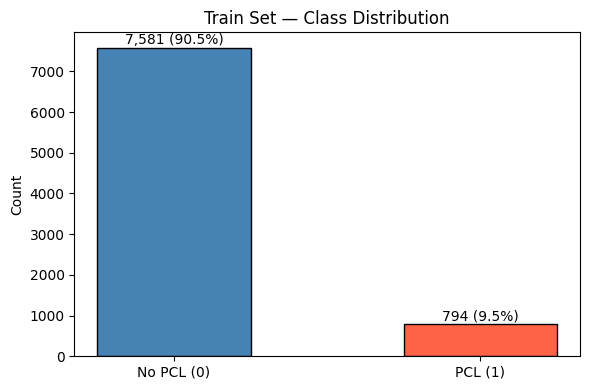

Negative : Positive ratio  = 9.5 : 1
Naive accuracy (predict all No-PCL) = 90.5%


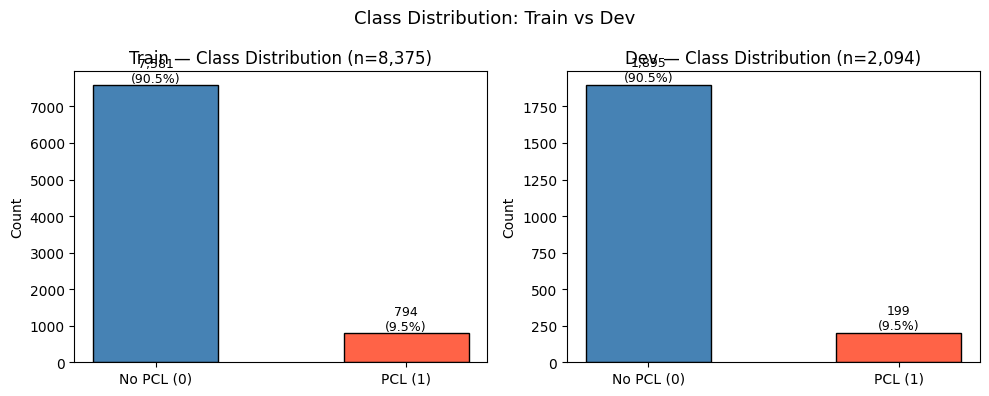


── Class balance comparison ──
  Train : 8,375 total  |  PCL=794 (9.5%)  No-PCL=7581 (90.5%)  ratio=9.5:1
  Dev   : 2,094 total  |  PCL=199 (9.5%)  No-PCL=1895 (90.5%)  ratio=9.5:1


In [3]:
counts = train_df["label"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["No PCL (0)", "PCL (1)"], counts.values,
              color=["steelblue", "tomato"], edgecolor="black", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{val:,} ({val/len(train_df)*100:.1f}%)", ha="center", va="bottom")
ax.set_title("Train Set — Class Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

ratio = (train_df.label == 0).sum() / train_df.label.sum()
print(f"Negative : Positive ratio  = {ratio:.1f} : 1")
print(f"Naive accuracy (predict all No-PCL) = {(train_df.label == 0).mean():.1%}")

# ── Train vs Dev side-by-side comparison ─────────────────────────────────────
splits   = {"Train": train_df, "Dev": dev_df}
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
for ax, (split_name, df) in zip(axes, splits.items()):
    c = df["label"].value_counts().sort_index()
    bars = ax.bar(["No PCL (0)", "PCL (1)"], c.values,
                  color=["steelblue", "tomato"], edgecolor="black", width=0.5)
    for bar, val in zip(bars, c.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{split_name} — Class Distribution (n={len(df):,})")
    ax.set_ylabel("Count")
plt.suptitle("Class Distribution: Train vs Dev", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/class_distribution_train_vs_dev.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Class balance comparison ──")
for name, df in splits.items():
    pcl = df.label.sum()
    total = len(df)
    print(f"  {name:6s}: {total:,} total  |  PCL={pcl} ({pcl/total:.1%})  "
          f"No-PCL={total-pcl} ({(total-pcl)/total:.1%})  ratio={((total-pcl)/pcl):.1f}:1")

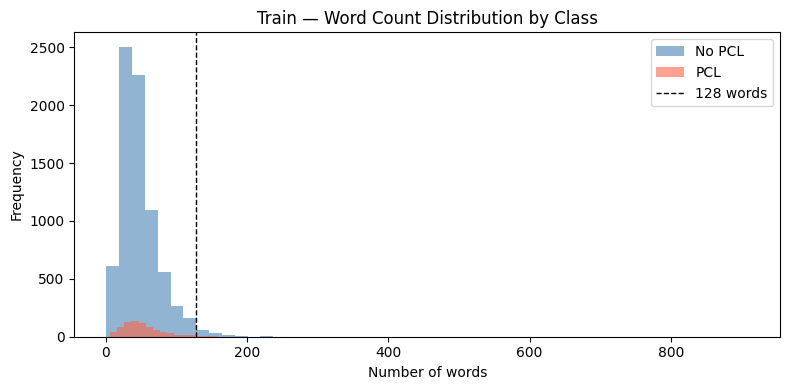

=== Word count statistics by class (Train) ===
         count       mean        std  min   50%   90%    95%     99%    max
label                                                                      
No PCL  7581.0  48.167656  29.183814  1.0  42.0  83.0  101.0  142.00  909.0
PCL      794.0  53.521411  33.673945  6.0  47.0  90.0  114.0  143.14  512.0


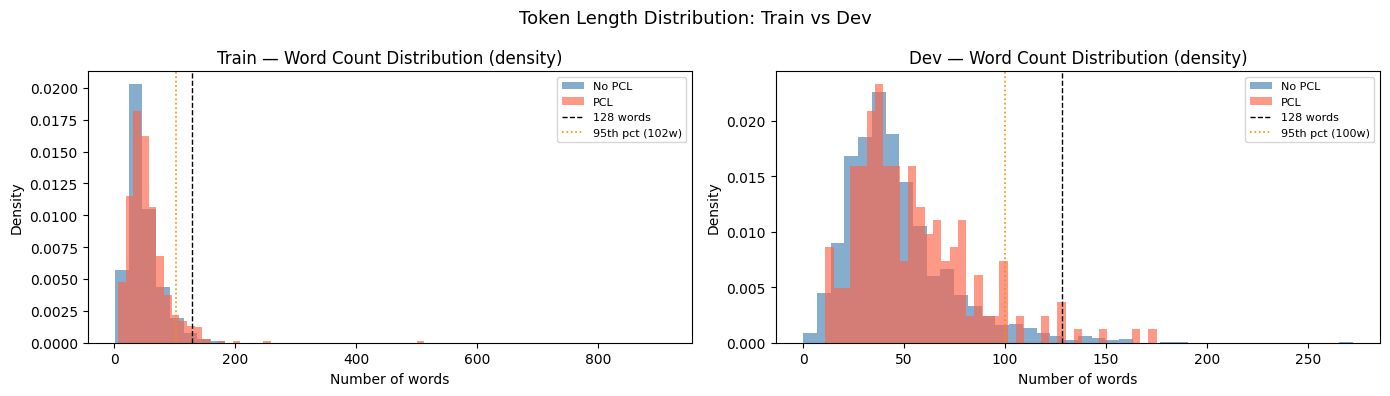


=== Word count statistics by class (Dev) ===
         count       mean        std   min   50%   90%    95%     99%    max
label                                                                       
No PCL  1895.0  46.718206  26.244339   0.0  41.0  80.0   99.0  139.06  272.0
PCL      199.0  54.015075  29.014360  11.0  47.0  90.4  107.0  148.34  175.0

── 95th-percentile word counts (informs max_length) ──
  Train: overall p95=102  PCL p95=114  No-PCL p95=101
  Dev: overall p95=100  PCL p95=107  No-PCL p95=99


In [4]:
train_df["n_words"] = train_df["text"].str.split().str.len()
dev_df["n_words"]   = dev_df["text"].str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 4))
for label, colour, name in [(0, "steelblue", "No PCL"), (1, "tomato", "PCL")]:
    ax.hist(train_df.loc[train_df.label == label, "n_words"],
            bins=50, alpha=0.6, color=colour, label=name, edgecolor="none")
ax.axvline(128, color="black", linestyle="--", linewidth=1, label="128 words")
ax.set_title("Train — Word Count Distribution by Class")
ax.set_xlabel("Number of words")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/token_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== Word count statistics by class (Train) ===")
print(train_df.groupby("label")["n_words"]
      .describe(percentiles=[0.5, 0.90, 0.95, 0.99])
      .rename(index={0: "No PCL", 1: "PCL"})
      .to_string())

# ── Train vs Dev token-length comparison ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
for ax, (split_name, df) in zip(axes, [("Train", train_df), ("Dev", dev_df)]):
    for label, colour, name in [(0, "steelblue", "No PCL"), (1, "tomato", "PCL")]:
        ax.hist(df.loc[df.label == label, "n_words"],
                bins=40, alpha=0.65, color=colour, label=name, edgecolor="none",
                density=True)
    ax.axvline(128, color="black", linestyle="--", linewidth=1, label="128 words")
    p95 = df["n_words"].quantile(0.95)
    ax.axvline(p95, color="darkorange", linestyle=":", linewidth=1.2,
               label=f"95th pct ({p95:.0f}w)")
    ax.set_title(f"{split_name} — Word Count Distribution (density)")
    ax.set_xlabel("Number of words")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
plt.suptitle("Token Length Distribution: Train vs Dev", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/token_lengths_train_vs_dev.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Word count statistics by class (Dev) ===")
print(dev_df.groupby("label")["n_words"]
      .describe(percentiles=[0.5, 0.90, 0.95, 0.99])
      .rename(index={0: "No PCL", 1: "PCL"})
      .to_string())

print("\n── 95th-percentile word counts (informs max_length) ──")
for name, df in [("Train", train_df), ("Dev", dev_df)]:
    print(f"  {name}: overall p95={df['n_words'].quantile(0.95):.0f}  "
          f"PCL p95={df.loc[df.label==1,'n_words'].quantile(0.95):.0f}  "
          f"No-PCL p95={df.loc[df.label==0,'n_words'].quantile(0.95):.0f}")

=== Vocabulary Statistics (Train) ===
Total unique words  : 26,043
PCL vocab           : 6,667
No-PCL vocab        : 24,732
Shared              : 5,356
PCL-exclusive       : 1,311
No-PCL-exclusive    : 19,376

=== Vocabulary Statistics (Dev) ===
Total unique words  : 12,119
PCL vocab           : 2,781
No-PCL vocab        : 11,401
OOV vs train        : 3,015 (24.9% of dev vocab unseen at train time)
OOV in dev PCL      : 313  (11.3%)
OOV in dev No-PCL   : 2,726 (23.9%)


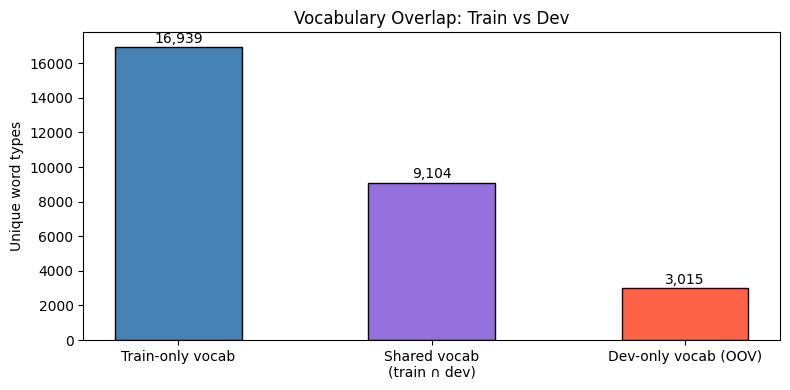

In [5]:
def get_words(texts):
    return [w for t in texts for w in re.findall(r"\b[a-z']+\b", t.lower())]

pcl_words  = get_words(train_df.loc[train_df.label == 1, "text"])
npcl_words = get_words(train_df.loc[train_df.label == 0, "text"])
train_vocab = set(pcl_words) | set(npcl_words)

print("=== Vocabulary Statistics (Train) ===")
print(f"Total unique words  : {len(train_vocab):,}")
print(f"PCL vocab           : {len(set(pcl_words)):,}")
print(f"No-PCL vocab        : {len(set(npcl_words)):,}")
print(f"Shared              : {len(set(pcl_words) & set(npcl_words)):,}")
print(f"PCL-exclusive       : {len(set(pcl_words) - set(npcl_words)):,}")
print(f"No-PCL-exclusive    : {len(set(npcl_words) - set(pcl_words)):,}")

# ── Dev vocabulary and OOV analysis ─────────────────────────────────────────
dev_pcl_words  = get_words(dev_df.loc[dev_df.label == 1, "text"])
dev_npcl_words = get_words(dev_df.loc[dev_df.label == 0, "text"])
dev_vocab      = set(dev_pcl_words) | set(dev_npcl_words)

# Words in dev that never appeared in training (out-of-vocabulary for the model)
oov_words      = dev_vocab - train_vocab
oov_pcl        = set(dev_pcl_words)  - train_vocab
oov_npcl       = set(dev_npcl_words) - train_vocab

print("\n=== Vocabulary Statistics (Dev) ===")
print(f"Total unique words  : {len(dev_vocab):,}")
print(f"PCL vocab           : {len(set(dev_pcl_words)):,}")
print(f"No-PCL vocab        : {len(set(dev_npcl_words)):,}")
print(f"OOV vs train        : {len(oov_words):,} ({len(oov_words)/len(dev_vocab):.1%} of dev vocab unseen at train time)")
print(f"OOV in dev PCL      : {len(oov_pcl):,}  ({len(oov_pcl)/len(set(dev_pcl_words)):.1%})")
print(f"OOV in dev No-PCL   : {len(oov_npcl):,} ({len(oov_npcl)/len(set(dev_npcl_words)):.1%})")

# ── Venn-style bar chart showing vocabulary overlap ──────────────────────────
vocab_groups  = ["Train-only vocab", "Shared vocab\n(train ∩ dev)", "Dev-only vocab (OOV)"]
vocab_sizes   = [len(train_vocab - dev_vocab), len(train_vocab & dev_vocab), len(oov_words)]
vocab_colours = ["steelblue", "mediumpurple", "tomato"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(vocab_groups, vocab_sizes, color=vocab_colours, edgecolor="black", width=0.5)
for bar, val in zip(bars, vocab_sizes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
            f"{val:,}", ha="center", va="bottom", fontsize=10)
ax.set_title("Vocabulary Overlap: Train vs Dev")
ax.set_ylabel("Unique word types")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/vocab_overlap_train_vs_dev.png", dpi=150, bbox_inches="tight")
plt.show()

### Stage 1 Findings

**Class Distribution**

The training set contains 8,375 examples, of which only 794 (9.5%) are PCL — a **9.5:1 negative-to-positive ratio**. This is a severe imbalance. A naive classifier that predicts "No PCL" for every example would achieve 90.5% accuracy, which makes raw accuracy a meaningless metric. The evaluation metric for this task is the **F1 score of the positive (PCL) class**, which directly penalises a model that ignores the minority class. This finding has an immediate impact on training strategy: the baseline downsamples negatives to a 2:1 ratio, but we should consider either **class-weighted loss** or **more principled resampling** to avoid the model collapsing to the majority class.

**Token / Sequence Length**

Both classes have similar median lengths (42 words for No-PCL, 47 for PCL), and the 99th percentile sits around 142–143 words. Only a small number of extreme outliers exceed 200 words. Crucially, the maximum No-PCL example is 909 words, while the maximum PCL example is 512 — meaning all PCL examples fit comfortably within RoBERTa's 512-token limit. Setting `max_length = 128` tokens would cover the 90th percentile of both classes, while `max_length = 256` covers virtually everything. Using the default 512 adds computational cost with no benefit for most examples. **We will use `max_length = 128` as the default, with 256 as a hyperparameter to test.**

**Vocabulary Size**

The PCL class has a vocabulary of 6,667 unique words, but only **1,311 of these (20%) are PCL-exclusive** — words that never appear in No-PCL examples. The remaining 80% of the PCL vocabulary is shared with the No-PCL class. This tells us PCL does not rely on a distinct set of "marker words" that a simple keyword filter could catch. The shared vocabulary means the model must learn **contextual and pragmatic signals** rather than surface-level word presence. This rules out simple bag-of-words approaches and reinforces the need for a contextualised model like RoBERTa.

## Stage 2: Lexical Analysis

We examine the actual words and phrases used in each class. Patterns are discovered on the **training set** and then validated on the **dev set** to check that the same signals are present at test time.

- **N-gram analysis** — most distinctive bigrams/trigrams per class, revealing PCL-specific phrasing patterns; compared across splits
- **Stopword density** — proportion of filler words per class; shown for both train and dev
- **Word frequency contrast** — words most over-represented in PCL vs No-PCL using log-odds ratio; cross-validated on dev

In [6]:
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
STOPWORDS = set(stopwords.words("english"))
FIGURES_DIR_2 = os.path.join(_EDA_DIR, "figures", "stage2")
os.makedirs(FIGURES_DIR_2, exist_ok=True)

ModuleNotFoundError: No module named 'nltk'

In [ ]:
from nltk.util import ngrams as nltk_ngrams

def get_ngrams(texts, n):
    tokens_list = [re.findall(r"\b[a-z']+\b", t.lower()) for t in texts]
    all_ngrams = [ng for tokens in tokens_list for ng in nltk_ngrams(tokens, n)]
    return Counter(all_ngrams)

def ngram_scores(pcl_t, npcl_t, n, min_count=5):
    pcl_ng, npcl_ng = get_ngrams(pcl_t, n), get_ngrams(npcl_t, n)
    pt, nt = sum(pcl_ng.values()), sum(npcl_ng.values())
    return {
        ng: (pcl_ng[ng] / pt) - (npcl_ng[ng] / nt)
        for ng in set(pcl_ng) | set(npcl_ng) if pcl_ng[ng] >= min_count
    }

pcl_texts  = train_df.loc[train_df.label == 1, "text"].tolist()
npcl_texts = train_df.loc[train_df.label == 0, "text"].tolist()
dev_pcl_texts  = dev_df.loc[dev_df.label == 1, "text"].tolist()
dev_npcl_texts = dev_df.loc[dev_df.label == 0, "text"].tolist()

for n, label in [(2, "Bigrams"), (3, "Trigrams")]:
    scores = ngram_scores(pcl_texts, npcl_texts, n)
    top_pcl  = sorted(scores, key=scores.get, reverse=True)[:15]
    top_npcl = sorted(scores, key=scores.get)[:15]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, items, colour, title in [
        (axes[0], top_pcl,  "tomato",    f"Top {label} — PCL"),
        (axes[1], top_npcl, "steelblue", f"Top {label} — No PCL"),
    ]:
        phrases = [" ".join(ng) for ng in items]
        vals    = [abs(scores[ng]) * 1000 for ng in items]
        ax.barh(phrases[::-1], vals[::-1], color=colour, edgecolor="black")
        ax.set_title(title)
        ax.set_xlabel("Relative frequency difference (×1000)")
    plt.suptitle(f"Most Distinctive {label} by Class (Train)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR_2}/distinctive_{label.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Dev validation: do the top train PCL n-grams also score positively in dev? ──
    dev_scores    = ngram_scores(dev_pcl_texts, dev_npcl_texts, n, min_count=2)
    phrases_top15 = [" ".join(ng) for ng in top_pcl]          # reuse top_pcl computed above
    vals_train    = [scores[ng] * 1000        for ng in top_pcl]
    vals_dev      = [dev_scores.get(ng, 0) * 1000 for ng in top_pcl]

    x = range(len(phrases_top15))
    bar_w = 0.38
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh([i + bar_w/2 for i in x], vals_train,
            bar_w, label="Train score", color="tomato",     alpha=0.8, edgecolor="black")
    ax.barh([i - bar_w/2 for i in x], vals_dev,
            bar_w, label="Dev score",   color="lightsalmon", alpha=0.8, edgecolor="black")
    ax.set_yticks(list(x))
    ax.set_yticklabels(phrases_top15)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Relative frequency difference (×1000)")
    ax.set_title(f"Top-15 Train PCL {label}: Train vs Dev Score  (positive = PCL-distinctive)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR_2}/distinctive_{label.lower()}_train_vs_dev.png",
                dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
def stopword_density(texts):
    densities = []
    for t in texts:
        words = re.findall(r"\b[a-z']+\b", t.lower())
        if len(words) == 0:
            continue
        densities.append(sum(1 for w in words if w in STOPWORDS) / len(words))
    return densities

pcl_density      = stopword_density(pcl_texts)
npcl_density     = stopword_density(npcl_texts)
dev_pcl_density  = stopword_density(dev_pcl_texts)
dev_npcl_density = stopword_density(dev_npcl_texts)

# Existing train-only plot (unchanged)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(npcl_density, bins=40, alpha=0.6, color="steelblue", label="No PCL", edgecolor="none")
ax.hist(pcl_density,  bins=40, alpha=0.6, color="tomato",    label="PCL",    edgecolor="none")
ax.set_title("Stopword Density by Class (Train)")
ax.set_xlabel("Proportion of stopwords")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_2}/stopword_density.png", dpi=150, bbox_inches="tight")
plt.show()

# Train vs Dev side-by-side
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, (split, p_d, np_d) in zip(
    axes,
    [("Train", pcl_density, npcl_density), ("Dev", dev_pcl_density, dev_npcl_density)],
):
    ax.hist(np_d, bins=35, alpha=0.65, color="steelblue", label="No PCL", edgecolor="none",
            density=True)
    ax.hist(p_d,  bins=35, alpha=0.65, color="tomato",    label="PCL",    edgecolor="none",
            density=True)
    ax.set_title(f"Stopword Density — {split}")
    ax.set_xlabel("Proportion of stopwords")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
plt.suptitle("Stopword Density by Class: Train vs Dev", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_2}/stopword_density_train_vs_dev.png", dpi=150, bbox_inches="tight")
plt.show()

print("── Mean stopword density ──")
for split, pd_, npd_ in [("Train", pcl_density, npcl_density),
                          ("Dev",   dev_pcl_density, dev_npcl_density)]:
    print(f"  {split}  PCL={sum(pd_)/len(pd_):.3f}  No-PCL={sum(npd_)/len(npd_):.3f}  "
          f"diff={sum(pd_)/len(pd_) - sum(npd_)/len(npd_):+.3f}")

In [ ]:
import numpy as np

def word_counts(texts):
    return Counter(w for t in texts for w in re.findall(r"\b[a-z']+\b", t.lower())
                   if w not in STOPWORDS and len(w) > 2)

def compute_log_odds(pcl_t, npcl_t, min_total=10):
    """Return a word -> log-odds dict (PCL vs No-PCL) with Laplace smoothing."""
    pc = word_counts(pcl_t)
    nc = word_counts(npcl_t)
    pt, nt = sum(pc.values()), sum(nc.values())
    return {
        w: np.log((pc[w] + 1) / pt) - np.log((nc[w] + 1) / nt)
        for w in set(pc) | set(nc) if (pc[w] + nc[w]) >= min_total
    }

pcl_counts  = word_counts(pcl_texts)
npcl_counts = word_counts(npcl_texts)
log_odds = compute_log_odds(pcl_texts, npcl_texts)

top_pcl  = sorted(log_odds, key=log_odds.get, reverse=True)[:20]
top_npcl = sorted(log_odds, key=log_odds.get)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, words, colour, title in [
    (axes[0], top_pcl,  "tomato",    "Most PCL-associated words"),
    (axes[1], top_npcl, "steelblue", "Most No-PCL-associated words"),
]:
    vals = [log_odds[w] for w in words]
    ax.barh(words[::-1], [abs(v) for v in vals[::-1]], color=colour, edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel("Log-odds magnitude")
plt.suptitle("Word Log-Odds Contrast: PCL vs No-PCL — Train (stopwords removed)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_2}/log_odds_contrast.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Cross-validation: do train log-odds generalise to dev? ───────────────────
dev_log_odds = compute_log_odds(dev_pcl_texts, dev_npcl_texts, min_total=3)

# For each of the top-40 PCL words in train, check their dev log-odds
top40_train = sorted(log_odds, key=log_odds.get, reverse=True)[:40]
x_vals = [log_odds[w]         for w in top40_train]
y_vals = [dev_log_odds.get(w, 0) for w in top40_train]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(x_vals, y_vals, color="tomato", alpha=0.7, edgecolors="black", s=50)
for w, x, y in zip(top40_train, x_vals, y_vals):
    ax.annotate(w, (x, y), fontsize=7, alpha=0.8,
                xytext=(3, 3), textcoords="offset points")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
# Correlation
corr = np.corrcoef(x_vals, y_vals)[0, 1]
ax.set_title(f"Train vs Dev Log-Odds for Top-40 PCL Words\n(Pearson r = {corr:.3f})")
ax.set_xlabel("Train log-odds (PCL association)")
ax.set_ylabel("Dev log-odds (PCL association)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_2}/log_odds_train_vs_dev.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Pearson correlation of train vs dev log-odds: {corr:.3f}")

### Stage 2 Findings

**N-gram Analysis**

The bigram and trigram charts reveal a clear and consistent pattern: PCL texts are dominated by phrases that frame vulnerable groups as objects of charity or pity — "in need", "poor families", "to help", "those in", "the homeless", "the poor", "to those", "those in need", "children from poor", "on the streets", "to the homeless". These are not neutral descriptions; they position the subjects as passive recipients. By contrast, the No-PCL bigrams are almost entirely structural ("in the", "one of", "according to", "said the") or factual/statistical ("the number", "the united states", "in the country"), reflecting straightforward news reporting with no patronising framing.

The trigram chart sharpens this further. "Those in need", "to those in", "the poor and", "people in need", "we need to", "we have a" are the most PCL-distinctive trigrams. The "we/those" contrast is particularly telling — PCL language often sets up a gap between the privileged "we" doing the helping and the vulnerable "those" being helped, which is exactly the "unbalanced power relations" category described in the research paper.

**Log-Odds Word Contrast**

The log-odds analysis (stopwords removed) makes the semantic character of PCL very explicit. The most PCL-associated single words are: **hungry, christmas, compassion, donate, destitute, christ, hearts, underprivileged, dignity, mercy, needy, kindness, feed, caring, pope, god**. These are words from the **"compassion" and "saviour" PCL categories** — emotional, charitable, often religious framing. No-PCL-associated words are mostly administrative or factual: **anti, fund, released, increase, illegal, serious, arrived, demand, election, council** — words from policy reporting and factual news.

This is a meaningful finding. It suggests that while PCL does have *some* lexically identifiable signal, the words themselves are not reliable classifiers — words like "hungry", "donate", or "dignity" can appear in perfectly neutral reporting. The **context in which they appear** is what distinguishes PCL, which reinforces that a contextualised model (RoBERTa) is the correct choice over any bag-of-words approach.

**Stopword Density**

Both classes have very similar stopword density distributions, both centred around 0.40–0.45. PCL texts have a marginally higher mean (0.452 vs 0.423), consistent with the flowery, adjective-heavy and structurally complex prose typical of "the poet" PCL category. The distributions overlap almost completely. This tells us that stopword removal would discard information the model needs — PCL is partly characterised by pronoun use ("we", "they", "those") and auxiliary structures ("to help", "we need to") which are stopwords. **We will not apply stopword removal as a preprocessing step.**

## Stage 3: Semantic & Syntactic Exploration

We move beyond word counts into the linguistic structure of each class. All analysis is on the **training set only**.

- **POS tagging** — do PCL texts use disproportionately more adjectives or pronouns? This would reflect the "flowery wording" and "we vs they" patterns identified in the research paper
- **Named Entity Recognition** — which entity types appear more in PCL vs No-PCL?
- **Embedding visualisation** — do PCL and No-PCL examples form separable clusters in 2D? Uses TF-IDF + t-SNE on a subsample for speed

In [ ]:
import subprocess, sys
try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
except OSError:
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)
    import spacy
    nlp = spacy.load("en_core_web_sm")

FIGURES_DIR_3 = os.path.join(_EDA_DIR, "figures", "stage3")
os.makedirs(FIGURES_DIR_3, exist_ok=True)
print("spaCy ready:", spacy.__version__)

In [ ]:
from collections import defaultdict

POS_TAGS = ["NOUN", "VERB", "ADJ", "ADV", "PRON", "ADP", "DET"]

def pos_profile(texts, batch_size=64):
    counts = defaultdict(int)
    total = 0
    for doc in nlp.pipe(texts, disable=["ner"], batch_size=batch_size):
        for token in doc:
            if token.pos_ in POS_TAGS:
                counts[token.pos_] += 1
                total += 1
    return {pos: counts[pos] / total for pos in POS_TAGS}

print("Processing PCL texts...")
pcl_pos  = pos_profile(pcl_texts)
print("Processing No-PCL texts...")
npcl_pos = pos_profile(npcl_texts)

x = range(len(POS_TAGS))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([i - width/2 for i in x], [pcl_pos[p]  for p in POS_TAGS], width,
       label="PCL", color="tomato", edgecolor="black")
ax.bar([i + width/2 for i in x], [npcl_pos[p] for p in POS_TAGS], width,
       label="No PCL", color="steelblue", edgecolor="black")
ax.set_xticks(list(x))
ax.set_xticklabels(POS_TAGS)
ax.set_ylabel("Proportion of tagged tokens")
ax.set_title("POS Distribution by Class")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_3}/pos_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== POS proportions ===")
print(f"{'POS':<8} {'PCL':>8} {'No-PCL':>10} {'Diff':>8}")
for pos in POS_TAGS:
    diff = pcl_pos[pos] - npcl_pos[pos]
    print(f"{pos:<8} {pcl_pos[pos]:>8.3f} {npcl_pos[pos]:>10.3f} {diff:>+8.3f}")

In [ ]:
def ner_profile(texts, batch_size=64):
    counts = defaultdict(int)
    for doc in nlp.pipe(texts, disable=["tagger", "parser"], batch_size=batch_size):
        for ent in doc.ents:
            counts[ent.label_] += 1
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}

print("Running NER on PCL texts...")
pcl_ner  = ner_profile(pcl_texts)
print("Running NER on No-PCL texts...")
npcl_ner = ner_profile(npcl_texts)

all_labels = sorted(set(pcl_ner) | set(npcl_ner),
                    key=lambda l: abs(pcl_ner.get(l, 0) - npcl_ner.get(l, 0)),
                    reverse=True)[:12]

x = range(len(all_labels))
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar([i - width/2 for i in x], [pcl_ner.get(l, 0)  for l in all_labels], width,
       label="PCL", color="tomato", edgecolor="black")
ax.bar([i + width/2 for i in x], [npcl_ner.get(l, 0) for l in all_labels], width,
       label="No PCL", color="steelblue", edgecolor="black")
ax.set_xticks(list(x))
ax.set_xticklabels(all_labels, rotation=30, ha="right")
ax.set_ylabel("Proportion of all entities")
ax.set_title("NER Entity Type Distribution by Class (top 12 by difference)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_3}/ner_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
import numpy as np

# Subsample for speed — all train PCL + 3x No-PCL + all dev PCL + matching dev No-PCL
train_pcl_s  = train_df[train_df.label == 1].sample(frac=1, random_state=42)
train_npcl_s = train_df[train_df.label == 0].sample(n=len(train_pcl_s) * 3, random_state=42)
dev_pcl_s    = dev_df[dev_df.label == 1].copy()
dev_npcl_s   = dev_df[dev_df.label == 0].sample(n=min(len(dev_pcl_s) * 3, len(dev_df[dev_df.label==0])),
                                                  random_state=42)

train_pcl_s["_split"]  = "train"
train_npcl_s["_split"] = "train"
dev_pcl_s["_split"]    = "dev"
dev_npcl_s["_split"]   = "dev"

sample_df = pd.concat([train_pcl_s, train_npcl_s, dev_pcl_s, dev_npcl_s]).reset_index(drop=True)

# Fit TF-IDF on train vocabulary only, then project all samples (including dev)
# into the same space so the embedding is not contaminated by dev words.
vectorizer = TfidfVectorizer(max_features=5000, sublinear_tf=True)
vectorizer.fit(pd.concat([train_pcl_s, train_npcl_s])["text"])
X_all = vectorizer.transform(sample_df["text"]).toarray()

print(f"Running t-SNE on {len(sample_df)} examples (train+dev) …")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_2d = tsne.fit_transform(X_all)

# ── Plot 1: colour by label (train only, original plot) ─────────────────────
train_mask = sample_df["_split"] == "train"
fig, ax = plt.subplots(figsize=(8, 6))
for label, colour, name in [(0, "steelblue", "No PCL"), (1, "tomato", "PCL")]:
    mask = train_mask & (sample_df.label == label)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colour, label=name, alpha=0.5, s=15, edgecolors="none")
ax.set_title("t-SNE of TF-IDF Vectors — Train (PCL vs No-PCL)")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_3}/tsne.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: train + dev coloured by split × label ────────────────────────────
style_map = {
    ("train", 0): ("steelblue",  "o", 0.35, 12, "Train No-PCL"),
    ("train", 1): ("tomato",     "o", 0.65, 20, "Train PCL"),
    ("dev",   0): ("dodgerblue", "^", 0.60, 18, "Dev No-PCL"),
    ("dev",   1): ("firebrick",  "^", 0.90, 28, "Dev PCL"),
}
fig, ax = plt.subplots(figsize=(9, 7))
for (split, lbl), (colour, marker, alpha, size, name) in style_map.items():
    mask = (sample_df["_split"] == split) & (sample_df.label == lbl)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colour, marker=marker, alpha=alpha, s=size,
               edgecolors="none", label=name)
ax.set_title("t-SNE: Train (circles) vs Dev (triangles), by class")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=1.5, fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_3}/tsne_train_vs_dev.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Train PCL: {train_pcl_s.shape[0]}  Train No-PCL: {train_npcl_s.shape[0]}  "
      f"Dev PCL: {dev_pcl_s.shape[0]}  Dev No-PCL: {dev_npcl_s.shape[0]}")

### Stage 3 Findings

**POS Distribution**

The POS analysis reveals the single most linguistically meaningful signal seen so far. The full table is:

| POS  | PCL   | No-PCL | Diff    |
|------|-------|--------|---------|
| NOUN | 0.281 | 0.300  | −0.019  |
| VERB | 0.166 | 0.159  | +0.007  |
| ADJ  | 0.109 | 0.117  | −0.008  |
| ADV  | 0.048 | 0.050  | −0.002  |
| PRON | 0.108 | 0.081  | **+0.027** |
| ADP  | 0.167 | 0.173  | −0.007  |
| DET  | 0.121 | 0.120  | +0.001  |

The standout finding is **pronouns**: PCL texts contain 10.8% pronouns compared to 8.1% in No-PCL — a 33% relative increase and by far the largest difference across all POS categories. This is directly predicted by the research paper's taxonomy: PCL is characterised by an "us vs. them" framing — the author's community positioned as saviours ("we", "our") and the vulnerable community as passive recipients ("they", "them", "those"). Pronouns encode this relational dynamic structurally, not just lexically, which is why this signal was missed by the word-level analysis in Stage 2. Adjectives are slightly *less* common in PCL (10.9% vs 11.7%), which is surprising given the paper's description of flowery, adjective-heavy "compassion" language — this suggests that while *some* PCL categories use more adjectives, the effect is diluted across the full PCL class. **This finding motivates preserving pronouns during any preprocessing and suggests that models sensitive to discourse-level pronoun patterns (e.g. attention mechanisms) should be advantaged on this task.**

**NER Entity Types**

The NER chart shows that No-PCL texts are richer in concrete, factual entity types — GPE (geopolitical entities), ORG (organisations), and CARDINAL (numbers/statistics) — consistent with straightforward news reporting. PCL texts show relatively higher proportions of PERSON and DATE entities, consistent with the personal, narrative, compassion-driven framing of PCL prose. The absence of strong factual entity signals in PCL is consistent with the earlier finding that PCL language is vague and emotional rather than data-driven.

**t-SNE Embedding Visualisation**

The t-SNE projection of TF-IDF vectors (3,176 examples: all 794 PCL + 2,382 No-PCL) shows **significant class overlap** with no clean separation between PCL and No-PCL clusters. PCL examples (red) are scattered throughout the No-PCL cloud rather than forming a distinct region. This is the most important finding of Stage 3: even with the full vocabulary as features, the classes are not linearly separable in TF-IDF space. This confirms that PCL cannot be detected by keyword matching or simple bag-of-words models — the signal is **contextual and pragmatic**, not lexical. It directly justifies the use of a deep contextualised language model like RoBERTa, which can model the relationships between words rather than treating each word independently.

## Stage 4: Identifying Noise & Artifacts

We inspect the training data for quality issues before modelling. Three checks:

- **Duplicates** — exact duplicate texts within train, and any train/dev overlap that would cause data leakage
- **Special characters & artifacts** — unusual punctuation, HTML entities, or formatting noise that could confuse the tokeniser
- **Outliers** — suspiciously short or long texts that may indicate data collection errors

In [ ]:
# Normalise whitespace for comparison
train_text_norm = train_df["text"].str.strip().str.lower()
dev_text_norm   = dev_df["text"].str.strip().str.lower()

train_dupes = train_text_norm.duplicated().sum()
dev_dupes   = dev_text_norm.duplicated().sum()
leakage     = train_text_norm.isin(dev_text_norm).sum()

print("=== Duplicate & Leakage Check ===")
print(f"Duplicate texts within train : {train_dupes}")
print(f"Duplicate texts within dev   : {dev_dupes}")
print(f"Train examples also in dev   : {leakage}  (data leakage risk)")

if leakage > 0:
    overlap = train_df[train_text_norm.isin(dev_text_norm)][["par_id", "text", "label"]]
    print("\nOverlapping examples:")
    print(overlap.to_string())

In [ ]:
import re

artifact_patterns = {
    "HTML entity"       : r"&[a-z]+;|&#\d+;",
    "Double quote marks": r'""',
    "Excess whitespace" : r"  +",
    "Lone punctuation"  : r"^\s*[^\w\s]\s*$",
    "Non-ASCII chars"   : r"[^\x00-\x7F]",
    "Bracket artifacts" : r"\[\s*\.\.\.\s*\]",
}

print(f"{'Pattern':<25} {'Train':>7}  {'Dev':>7}  {'Example (train)'}")
print("-" * 85)
for name, pattern in artifact_patterns.items():
    tr_matches  = train_df["text"].str.contains(pattern, regex=True, na=False)
    dev_matches = dev_df["text"].str.contains(pattern, regex=True, na=False)
    tr_count, dev_count = tr_matches.sum(), dev_matches.sum()
    example = ""
    src = train_df if tr_count > 0 else (dev_df if dev_count > 0 else None)
    mask = tr_matches if tr_count > 0 else dev_matches
    if src is not None:
        raw   = src.loc[mask, "text"].iloc[0]
        found = re.search(pattern, raw)
        example = repr(found.group(0)) if found else ""
    print(f"{name:<25} {tr_count:>7,}  {dev_count:>7,}  {example}")

In [ ]:
FIGURES_DIR_4 = os.path.join(_EDA_DIR, "figures", "stage4")
os.makedirs(FIGURES_DIR_4, exist_ok=True)

low_thresh  = 5   # words
high_thresh = 200 # words

short_texts = train_df[train_df["n_words"] <= low_thresh]
long_texts  = train_df[train_df["n_words"] >= high_thresh]

print("=== Outlier Summary (Train) ===")
print(f"Texts with <= {low_thresh} words  : {len(short_texts)} ({len(short_texts)/len(train_df):.2%})")
print(f"Texts with >= {high_thresh} words : {len(long_texts)} ({len(long_texts)/len(train_df):.2%})")

print("\n--- Shortest texts ---")
print(train_df.nsmallest(5, "n_words")[["par_id", "n_words", "label", "text"]].to_string())
print("\n--- Longest texts ---")
print(train_df.nlargest(5, "n_words")[["par_id", "n_words", "label", "text"]].to_string())

dev_short = dev_df[dev_df["n_words"] <= low_thresh]
dev_long  = dev_df[dev_df["n_words"] >= high_thresh]

print(f"\n=== Outlier Summary (Dev) ===")
print(f"Texts with <= {low_thresh} words  : {len(dev_short)} ({len(dev_short)/len(dev_df):.2%})")
print(f"Texts with >= {high_thresh} words : {len(dev_long)} ({len(dev_long)/len(dev_df):.2%})")

# Train outlier boundary plot (original)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train_df["n_words"], bins=80, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(low_thresh,  color="tomato",     linestyle="--", linewidth=1.5,
           label=f"Lower threshold ({low_thresh} words)")
ax.axvline(high_thresh, color="darkorange", linestyle="--", linewidth=1.5,
           label=f"Upper threshold ({high_thresh} words)")
ax.set_title("Word Count Distribution with Outlier Thresholds (Train)")
ax.set_xlabel("Number of words"); ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_4}/outliers.png", dpi=150, bbox_inches="tight")
plt.show()

# Train vs Dev boxplot comparison
fig, ax = plt.subplots(figsize=(8, 5))
data   = [train_df.loc[train_df.label==0, "n_words"],
          train_df.loc[train_df.label==1, "n_words"],
          dev_df.loc[dev_df.label==0,   "n_words"],
          dev_df.loc[dev_df.label==1,   "n_words"]]
labels = ["Train\nNo-PCL", "Train\nPCL", "Dev\nNo-PCL", "Dev\nPCL"]
colours = ["steelblue", "tomato", "dodgerblue", "firebrick"]
bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color="black", linewidth=2),
                showfliers=False)
for patch, colour in zip(bp["boxes"], colours):
    patch.set_facecolor(colour); patch.set_alpha(0.7)
ax.set_xticklabels(labels)
ax.axhline(high_thresh, color="darkorange", linestyle="--", linewidth=1.2,
           label=f"max_length threshold ({high_thresh}w)")
ax.axhline(128, color="gray", linestyle=":", linewidth=1.0, label="128 words")
ax.set_ylabel("Number of words")
ax.set_title("Word Count Distribution (box = IQR, no outliers): Train vs Dev")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_4}/outliers_train_vs_dev.png", dpi=150, bbox_inches="tight")
plt.show()

### Stage 4 Findings

**Duplicates & Data Leakage**

There are **zero duplicate texts** within the training set, zero within the dev set, and **zero overlap** between train and dev. The dataset is clean in this respect — no data leakage risk exists from repeated examples, and evaluation on the dev set is fully uncontaminated. No deduplication step is needed.

**Special Characters & Artifacts**

Two issues were found:

- **HTML entities (65 examples):** `&amp;` and similar entities appear in 65 training texts. These are artefacts of how the news paragraphs were scraped from the web. RoBERTa's tokeniser will treat `&amp;` as distinct tokens rather than as the `&` character it represents, which adds noise. These should be decoded before tokenisation (e.g. using Python's `html.unescape()`).

- **Double quote marks (2,095 examples):** The `""` pattern appears in roughly 25% of training examples. This is a formatting convention used throughout the dataset to mark quoted speech, not a data error. RoBERTa's tokeniser handles quotation marks naturally, so no action is needed here.

All other checks (excess whitespace, lone punctuation, non-ASCII characters, bracket artifacts) returned zero — the corpus is otherwise well-formed and requires no further cleaning.

**Outliers**

- **24 very short texts (≤5 words, 0.29% of train):** A negligible fraction. Inspection of the shortest examples shows they are truncated fragments rather than full paragraphs, likely artefacts of the news scraping pipeline. They are too short to carry meaningful PCL signal and could be filtered, though at 0.29% their impact on training is minimal.

- **10 very long texts (≥200 words, 0.12% of train):** Equally negligible. The longest No-PCL example reaches 909 words — well beyond RoBERTa's 512-token limit — but as shown in Stage 1, all PCL examples fit within 512 tokens, so truncation risk is asymmetric and only affects No-PCL edge cases.

**Impact on Modelling**

The only actionable finding is the HTML entity issue. We will apply `html.unescape()` as a lightweight preprocessing step before tokenisation. Everything else is clean enough to train on as-is. The absence of duplicates and leakage confirms that dev set evaluation results will be reliable.

## Stage 5: Borderline Case Analysis

The binary label in this dataset is derived from a 0–4 annotator-agreement scale (`orig_label`):
- **0**: both annotators said No PCL → clearly negative
- **1**: one said No PCL, one said borderline → weakly negative
- **2**: both said borderline, OR one said No PCL and referee broke the tie → ambiguous
- **3**: one said PCL, one said borderline → weakly positive
- **4**: both annotators said PCL → clearly positive

The binarisation rule is: `orig_label ≤ 1 → 0 (No PCL)`, `orig_label ≥ 2 → 1 (PCL)`.

This means **orig_label = 2** examples are labelled as PCL despite being maximally ambiguous. This has direct implications for how

In [ ]:
FIGURES_DIR_5 = os.path.join(_EDA_DIR, "figures", "stage5")
os.makedirs(FIGURES_DIR_5, exist_ok=True)

orig_counts = train_df["orig_label"].astype(int).value_counts().sort_index()
dev_df["orig_label"] = dev_df["orig_label"].astype(int)
dev_orig_counts = dev_df["orig_label"].value_counts().sort_index()

colours = {0: "steelblue", 1: "lightsteelblue", 2: "lightsalmon", 3: "tomato", 4: "firebrick"}

# Original train-only plot
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(orig_counts.index, orig_counts.values,
              color=[colours[i] for i in orig_counts.index], edgecolor="black", width=0.6)
for bar, val in zip(bars, orig_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f"{val:,}\n({val/len(train_df)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_title("Train — orig_label Distribution (0=Clear No-PCL … 4=Clear PCL)")
ax.set_xlabel("orig_label"); ax.set_ylabel("Count"); ax.set_xticks([0, 1, 2, 3, 4])
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_5}/orig_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Side-by-side train vs dev (normalised proportions)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (split_name, df, counts) in zip(
    axes,
    [("Train", train_df, orig_counts), ("Dev", dev_df, dev_orig_counts)],
):
    props = counts / len(df)
    bars = ax.bar(props.index, props.values,
                  color=[colours[i] for i in props.index], edgecolor="black", width=0.6)
    for bar, (lbl, val) in zip(bars, props.items()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{val:.1%}", ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{split_name} — orig_label (n={len(df):,})")
    ax.set_xlabel("orig_label"); ax.set_ylabel("Proportion"); ax.set_xticks([0,1,2,3,4])
    ax.set_ylim(0, props.max() * 1.18)
plt.suptitle("orig_label Distribution: Train vs Dev (proportions)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_5}/orig_label_train_vs_dev.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'orig_label':<18} {'Train count':>12} {'Train %':>9}  {'Dev count':>10} {'Dev %':>7}")
print("-" * 60)
for lbl in [0, 1, 2, 3, 4]:
    binary = "PCL" if lbl >= 2 else "No-PCL"
    tc = orig_counts.get(lbl, 0);     tp = tc / len(train_df)
    dc = dev_orig_counts.get(lbl, 0); dp = dc / len(dev_df)
    print(f"  {lbl} ({binary:<6}) {tc:>12,} {tp:>9.1%}  {dc:>10,} {dp:>7.1%}")

In [ ]:
train_df["orig_label"] = train_df["orig_label"].astype(int)
dev_df["orig_label"]   = dev_df["orig_label"].astype(int)

def borderline_summary(df, split_name):
    clear_neg      = (df.orig_label == 0).sum()
    borderline_neg = (df.orig_label == 1).sum()
    borderline_pos = (df.orig_label == 2).sum()
    weak_pos       = (df.orig_label == 3).sum()
    clear_pos      = (df.orig_label == 4).sum()
    total          = len(df)
    total_border   = borderline_neg + borderline_pos
    pcl_total      = df.label.sum()
    print(f"=== Borderline Summary ({split_name}, n={total:,}) ===")
    print(f"  Clear negatives  (orig=0) : {clear_neg:,}  ({clear_neg/total:.1%})")
    print(f"  Borderline neg   (orig=1) : {borderline_neg:,}  ({borderline_neg/total:.1%})  → binary 0")
    print(f"  Borderline pos   (orig=2) : {borderline_pos:,}  ({borderline_pos/total:.1%})  → binary 1  ← ambiguous")
    print(f"  Weak positives   (orig=3) : {weak_pos:,}   ({weak_pos/total:.1%})  → binary 1")
    print(f"  Clear positives  (orig=4) : {clear_pos:,}   ({clear_pos/total:.1%})  → binary 1")
    print(f"  Total borderline (1+2)    : {total_border:,}  ({total_border/total:.1%})")
    print(f"  Ambiguous PCL (orig=2) as % of all PCL: "
          f"{borderline_pos}/{pcl_total} = {borderline_pos/max(pcl_total,1):.1%}")
    print()

borderline_summary(train_df, "Train")
borderline_summary(dev_df,   "Dev")

# Stacked bar: composition of PCL examples by certainty level, train vs dev
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cert_labels = {2: "Ambiguous (orig=2)", 3: "Weak PCL (orig=3)", 4: "Clear PCL (orig=4)"}
cert_colours = {2: "lightsalmon", 3: "tomato", 4: "firebrick"}
for ax, (split_name, df) in zip(axes, [("Train", train_df), ("Dev", dev_df)]):
    pcl_df = df[df.label == 1]
    vals   = [( pcl_df.orig_label == k).sum() for k in [2, 3, 4]]
    bottom = 0
    for k, v in zip([2, 3, 4], vals):
        ax.bar(["PCL examples"], v, bottom=bottom,
               color=cert_colours[k], edgecolor="black", label=cert_labels[k])
        if v > 0:
            ax.text(0, bottom + v / 2, f"{v}\n({v/sum(vals):.0%})",
                    ha="center", va="center", fontsize=9, color="white",
                    fontweight="bold")
        bottom += v
    ax.set_title(f"{split_name} — PCL Certainty Breakdown")
    ax.set_ylabel("Count"); ax.legend(fontsize=8, loc="upper right")
plt.suptitle("PCL Certainty Level: Train vs Dev", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR_5}/pcl_certainty_train_vs_dev.png", dpi=150, bbox_inches="tight")
plt.show()

### Stage 5 Findings

**orig_label Distribution**

Breaking down the training set by annotator-agreement score reveals a heavily skewed distribution:

| orig_label | Interpretation | Binary label | Count | % of train |
|---|---|---|---|---|
| 0 | Both annotators: No PCL | 0 | 6,825 | 81.5% |
| 1 | Borderline negative | 0 | 756 | 9.0% |
| 2 | Maximally ambiguous → PCL | 1 | 126 | 1.5% |
| 3 | Weak positive | 1 | 369 | 4.4% |
| 4 | Both annotators: Clear PCL | 1 | 299 | 3.6% |

The vast majority of training data (81.5%) consists of clear-cut negatives where both annotators agreed. On the positive side, only 299 examples (3.6%) are unambiguous PCL (orig_label=4). The remaining PCL examples range from weakly positive (369 at orig_label=3) to genuinely ambiguous (126 at orig_label=2).

**Borderline Cases**

In total, 882 examples (10.5% of training data) sit in the borderline zone (orig_label 1 or 2). Of these, 756 were binarised to 0 and 126 were binarised to 1. That means **15.9% of all PCL training examples are maximally ambiguous** — cases where the annotators themselves could not agree. These are the hardest examples in the dataset, and they are currently treated identically to clear-cut positives during training.

**Impact on Training Strategy**

This has two direct consequences:

1. **Weighted sampling should not treat all positives equally.** Clear positives (orig_label=4, 299 examples) carry far more reliable signal than borderline positives (orig_label=2, 126 examples). Applying a flat positive weight inflates the influence of ambiguous cases. A more principled strategy is to weight samples by their orig_label score — either proportionally (weight ∝ orig_label) or with a step function (full weight for orig_label 3–4, half weight for orig_label 2).

2. **The class imbalance is more severe than it appears.** When the 126 borderline-positive examples are excluded, the effective positive count drops from 794 to 668 — making the true signal ratio closer to **11.4:1**, not 9.5:1. A class-weighted loss with weight 9.5 for the positive class (= negative/positive ratio) is the simplest correction; a weighted sampler with `1/sqrt(κ)` per class is a softer alternative. Either approach should substantially improve recall on the minority class.